In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.calibration import CalibrationDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
## -- Set Configuration --
class CFG:
    FOLDS = 5
    SEED = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RED    = '\033[31m'
    RESET  = '\033[0m'
    
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', # Outer panel (figure)
    'axes.facecolor':   '#1a1a2e', # Inner panel (plot)
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0ff',
    'text.color':       'lightblue',
    'xtick.color':      '#e0e0ff',
    'ytick.color':      '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

train[TARGET] = train[TARGET].astype(int)
orig[TARGET]  = orig[TARGET].astype(int)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")


Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [5]:
# ## -- Load data from Colab --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e1 | Student Test Score/student_test_dataset/'
# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
# test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
# orig = pd.read_csv(PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

# TARGET = train.columns[-1]
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [6]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [7]:
train.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


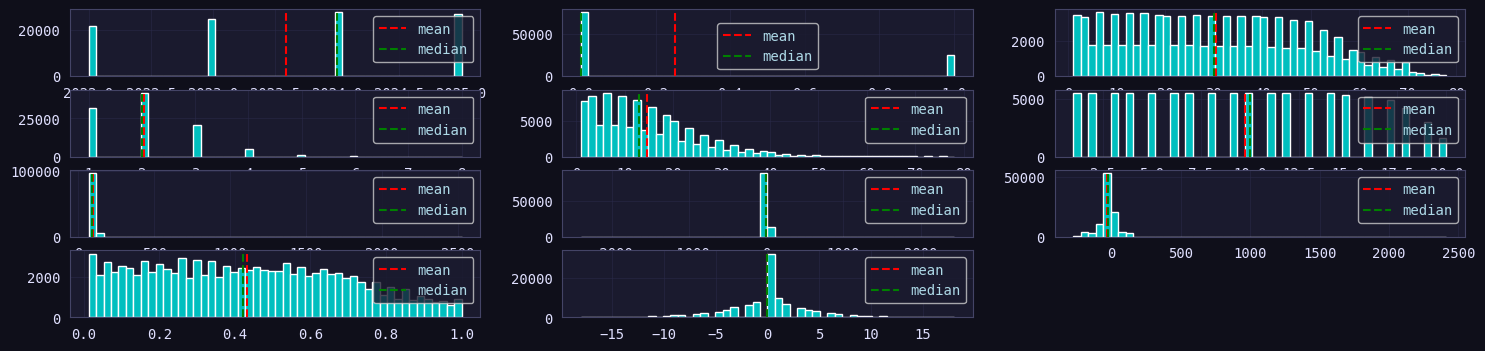

In [8]:
plt.figure(figsize=(18, 4))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.legend()
    
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
_extract_cols = ['Cumulative_Degradation', 'LapTime (s)'] # , 'LapTime_Delta'

print(f"\nRounding... ", end='')
for col in _extract_cols:
    for r in range(-2, 3):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDIGITS... ", end='')
    # for d in range(-3, 4):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [100]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nCreating quantile-based Q_BINS... ", end='')
    # for q in [100]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('-'*40)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


Rounding... Cumulative_Degradation_round_-2, Cumulative_Degradation_round_-1, Cumulative_Degradation_round_0, Cumulative_Degradation_round_1, Cumulative_Degradation_round_2, LapTime (s)_round_-2, LapTime (s)_round_-1, LapTime (s)_round_0, LapTime (s)_round_1, LapTime (s)_round_2, 
----------------------------------------
✅ Total ROUNDS: 10
✅ Total DIGITS: 0
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [13]:
# _extract_cols = ['TyreLife'] # , 'LapTime_Delta'

# for col in _extract_cols:
#     # print(f"\nRounding... ", end='')
#     # for r in [0, -1]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in [-1, 0]:
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [14]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Features dropped: []


Cumulative_Degradation_round_-2      7
Cumulative_Degradation_round_-1     51
Cumulative_Degradation_round_0     454
Cumulative_Degradation_round_1     447
Cumulative_Degradation_round_2     445
LapTime (s)_round_-2                 5
LapTime (s)_round_-1                25
LapTime (s)_round_0                137
LapTime (s)_round_1                134
LapTime (s)_round_2                132
dtype: int64

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
INTER = []
top_cols = ['Year', 'Compound', 'Stint', 'Race', 'PitStop'] 
low_cols = ['Driver', 'Position', 'Position_Change', 'LapNumber', 'TyreLife']

for c1, c2 in tqdm(list(itertools.combinations(top_cols, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/10 [00:00<?, ?it/s]

Total Interaction Features: 10


In [17]:
## -- Arithmetic interactions --
for df in [train, test, orig]:
    df['_LapNumber_div_RacePro'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
    df['_TyreLife_div_LapNum'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
    df['_lapTime_s_*_Cum_Deg'] = (df['LapTime (s)'] * df['Cumulative_Degradation']).astype('float32')
    df['_LapTime_s_*_Cum_abs'] = (df['LapTime (s)'] * df['Cumulative_Degradation'].abs()).astype('float32')
    df['_LapTime_s_div_Cum_abs'] = (df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + 1e-6)).astype('float32')

arithmetic = [
    '_LapNumber_div_RacePro',
    '_TyreLife_div_LapNum',
    '_lapTime_s_*_Cum_Deg',
    '_LapTime_s_*_Cum_abs',
    '_LapTime_s_div_Cum_abs',
]

print(f"Total Arithmetic interactions: {len(arithmetic)}")

train[arithmetic].head()

Total Arithmetic interactions: 5


,_LapNumber_div_RacePro,_TyreLife_div_LapNum,_lapTime_s_*_Cum_Deg,_LapTime_s_*_Cum_abs,_LapTime_s_div_Cum_abs
0,69.999901,0.780000,1649.802368,1649.802368,3.734288
1,77.999771,0.259259,-16761.730469,16761.730469,0.336437
2,71.999908,0.372881,-7132.029785,7132.029785,0.705717
3,25.999662,1.000000,-691.099976,691.099976,12.883805
4,71.999802,0.230769,-1525.286987,1525.286987,7.629817


In [18]:
## -- Frequency encoding --
freq_cols = []

print(f"\nCreating frequencies... ", end='')
for col in CATS: #  + arithmetic[:2] + ['RaceProgress']  
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    n = f'{col}_freq'
    print(f"{n}.. ", end='')
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    freq_cols.append(n)

print(f"\n✓ Total frequency features: {len(freq_cols)}")
train[freq_cols].describe()


Creating frequencies... Driver_freq.. Compound_freq.. Race_freq.. 
✓ Total frequency features: 3


,Driver_freq,Compound_freq,Race_freq
count,439140.000000,439140.000000,439140.000000
mean,0.002632,0.387627,0.041934
std,0.001749,0.125573,0.009372
min,0.000001,0.003187,0.007622
25%,0.001857,0.395496,0.035389
50%,0.002684,0.395496,0.043022
75%,0.002854,0.466199,0.048945
max,0.010526,0.466199,0.055289


In [19]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [21]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [22]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'],
#     # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )
# print(f"Original features merged: {len(orig_cols)}")

In [23]:
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [24]:
## -- Flag 'Year' == 2023 --
for df in [train, test, orig]:
    df['is_2023'] = (df['Year'] == 2023).astype(int)
    # df['is_pre_season'] = (df['Race'] == 'Pre-Season Testing').astype(int)

print('Flag columns created')

Flag columns created


In [25]:
# _, axs = plt.subplots(1, 2, figsize=(15, 5))
# train['is_pre_season'].value_counts().plot.bar(ax=axs[0])
# train['is_2023'].value_counts().plot.bar(ax=axs[1])
# plt.show()

In [26]:
## -- Factorize combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c], orig[c]])
    combined = combined.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combined[:len(train)]
    test[c]  = combined[len(train):len(train)+len(test)]
    orig[c]  = combined[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [27]:
train.nunique().sort_values()

PitStop                                 2
PitNextLap                              2
is_2023                                 2
Year                                    4
LapTime (s)_round_-2                    5
Compound                                5
Compound_freq                           5
Cumulative_Degradation_round_-2         7
Bi_Year-|-PitStop                       8
Stint                                   8
Bi_Compound-|-PitStop                  10
Bi_Stint-|-PitStop                     15
Position                               20
Bi_Year-|-Compound                     20
LapTime (s)_round_-1                   25
Race                                   26
Race_freq                              26
Bi_Year-|-Stint                        28
Bi_Compound-|-Stint                    36
Position_Change                        37
Cumulative_Degradation_round_-1        51
Bi_Race-|-PitStop                      52
TyreLife                               78
LapNumber                         

In [28]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 43


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Year-|-PitStop,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Compound-|-PitStop,Bi_Stint-|-Race,Bi_Stint-|-PitStop,Bi_Race-|-PitStop,_LapNumber_div_RacePro,_TyreLife_div_LapNum,_lapTime_s_*_Cum_Deg,_LapTime_s_*_Cum_abs,_LapTime_s_div_Cum_abs,Driver_freq,Compound_freq,Race_freq,is_2023
0,0,0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1,0,20,21,21,21,100,80,78,78,78,2022_HARD,2022_2,2022_Canadian Grand Prix,2022_0,HARD_2,HARD_Canadian Grand Prix,HARD_0,2_Canadian Grand Prix,2_0,Canadian Grand Prix_0,69.999901,0.780000,1649.802368,1649.802368,3.734288,0.002034,0.395496,0.048945,0
1,1,0,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0,-200,-220,-223,-223,-223,100,80,75,75,75,2025_HARD,2025_2,2025_Dutch Grand Prix,2025_1,HARD_2,HARD_Dutch Grand Prix,HARD_1,2_Dutch Grand Prix,2_1,Dutch Grand Prix_1,77.999771,0.259259,-16761.730469,16761.730469,0.336437,0.002207,0.395496,0.055289,0
2,2,0,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1,-100,-100,-101,-100,-100,100,70,71,70,70,2022_HARD,2022_3,2022_Austrian Grand Prix,2022_0,HARD_3,HARD_Austrian Grand Prix,HARD_0,3_Austrian Grand Prix,3_0,Austrian Grand Prix_0,71.999908,0.372881,-7132.029785,7132.029785,0.705717,0.002893,0.395496,0.047861,0


# ML TRAINING

In [29]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats, use_orig=True):
    print(f"\n========== Starting Cross-Validation for {model_name} ===========")
    start = time()

    X = train_df[features]
    y = train_df[target]

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx+1}/{kf.n_splits} | ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        if use_orig:
            ## -- OPTION A: Concatenate original data --
            X_train = pd.concat([X_train, orig[features]], ignore_index=True)
            y_train = pd.concat([y_train, orig[target]], ignore_index=True)
            # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)
    
            # ## -- OPTION B: TE merge original data --
            # X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
            #     orig,
            #     X_train,
            #     X_valid,
            #     X_test,
            #     features=BASE,
            #     target=TARGET,
            #     aggs=['mean'], # mean, median, count, std, nunique, max, min
            #     fill_nan=True,
            # )

        # print(f"Category Mean Encoding: {len(cme_features)} | ", end='')
        # cme_enc = CategoryMeanTransformer(cat_cols=[c])
        # X_train[n] = cme_enc.fit_transform(X_train, y_train)
        # X_valid[n] = cme_enc.transform(X_valid)
        # X_test[n]  = cme_enc.transform(X_test)

        ## -- TE Opt1. -> Using CUSTOM --
        te_enc  = TargetEncoder(INTER+['Driver'], cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test  = te_enc.transform(X_test)

        ## -- TE Opt1. -> Using CUSTOM --
        te_enc1 = TargetEncoder(['Race'], cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        X_train = te_enc1.fit_transform(X_train, y_train)
        X_valid = te_enc1.transform(X_valid)
        X_test  = te_enc1.transform(X_test)
        
        # tv_enc  = TableVectorizer(drop_if_constant=True, n_jobs=os.cpu_count())
        # X_train = tv_enc.fit_transform(X_train, y_train.to_numpy())
        # X_valid = tv_enc.transform(X_valid)
        # X_test  = tv_enc.transform(X_test)

        combined = pd.concat([X_train, X_valid, X_test])
        for c in cats:
            combined[c] = combined[c].astype(str).astype('category')
        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape} *****")

        if 'hist' in model_name:
            model = HistGradientBoostingClassifier(**params)
            model.fit(X_train, y_train)
        elif 'xtr' in model_name:
            model = ExtraTreesClassifier(**params)
            model.fit(X_train, y_train)

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1]

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'{CFG.YELLOW} • Fold {idx+1}: {fold_auc:.5f}{CFG.RESET}')

        ## -- Clean up memory -- X_valid
        del X_train, y_train, y_valid, X_test
        gc.collect()

    ## -- Average the test predictions
    test_preds /= kf.n_splits

    ## -- Print CV results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    
    for i, score in enumerate(fold_scores):
        print(f" • Fold {i+1} score: {score:.5f}")
    
    ## -- Calculate out-of-fold AUC
    oof_auc = np.round(roc_auc_score(y, oof_preds), 5)
    
    print("------------------------------------------------- |")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("------------------------------------------------- |")
    print(f'{((time() - start) / 60):.2f} mins\n')
    
    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
        'val_data': X_valid,
    }

print('⚙️ Training function ready ⚙️')

⚙️ Training function ready ⚙️


In [30]:
x_sample, x_sample2 = train_test_split(train, test_size=0.5, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Year-|-PitStop,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Compound-|-PitStop,Bi_Stint-|-Race,Bi_Stint-|-PitStop,Bi_Race-|-PitStop,_LapNumber_div_RacePro,_TyreLife_div_LapNum,_lapTime_s_*_Cum_Deg,_LapTime_s_*_Cum_abs,_LapTime_s_div_Cum_abs,Driver_freq,Compound_freq,Race_freq,is_2023
224498,233,1,24,2025,0,21,1,21.0,17,98.947,-7.958,147.346,0.276316,-9.0,0,100,150,147,147,147,100,100,99,98,98,2025_MEDIUM,2025_1,2025_Singapore Grand Prix,2025_0,MEDIUM_1,MEDIUM_Singapore Grand Prix,MEDIUM_0,1_Singapore Grand Prix,1_0,Singapore Grand Prix_0,75.999725,1.0,14579.444336,14579.444336,0.671528,0.003233,0.466199,0.043022,0
195066,47,0,23,2025,0,12,2,12.0,17,81.867,-16.080,-7.124,0.157895,-9.0,1,0,-10,-7,-7,-7,100,80,82,81,81,2025_HARD,2025_2,2025_Emilia Romagna Grand Prix,2025_0,HARD_2,HARD_Emilia Romagna Grand Prix,HARD_0,2_Emilia Romagna Grand Prix,2_0,Emilia Romagna Grand Prix_0,75.999519,1.0,-583.220520,583.220520,11.491716,0.002794,0.395496,0.035389,0
184622,373,1,8,2023,0,3,1,6.0,1,86.539,-0.053,-1.053,0.058824,0.0,0,0,0,-1,-1,-1,100,90,87,86,86,2023_MEDIUM,2023_1,2023_Italian Grand Prix,2023_0,MEDIUM_1,MEDIUM_Italian Grand Prix,MEDIUM_0,1_Italian Grand Prix,1_0,Italian Grand Prix_0,50.999134,2.0,-91.125565,91.125565,82.183205,0.000571,0.466199,0.044304,1


In [31]:
all_model_predictions = {}

MULTI_SEEDS = [CFG.SEED, 777, 1234, 24611, 0]
ALL_CATS = ['Compound', 'Race']

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

kf = StratifiedKFold(n_splits=CFG.FOLDS, shuffle=True, random_state=CFG.SEED)
kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# HISTOGRAM

In [32]:
version_name = 'hist_orig_'

if all_model_predictions:
    all_model_predictions.clear()

PARAMS = {
    'max_iter': 5000,
    'learning_rate': 0.05,
    'max_features': 0.1,
    'n_iter_no_change': 100,
    'l2_regularization': 5.0,
    # 'scoring': 'loss', # 'loss', 'roc_auc'
    'tol': 1e-5,
    'verbose': 1,
    'random_state': CFG.SEED,
}

for VALUE in [True, False]:
    # PARAMS['scoring'] = VALUE
    n = version_name + str(VALUE)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
        use_orig=VALUE,
    )


========== Starting Cross-Validation for hist_orig_True ===========

***** FOLD 1/5 | Train shape: (452683, 44) *****
Binning 0.143 GB of training data: 1.191 s
Binning 0.016 GB of validation data: 0.080 s
Fitting gradient boosted rounds:
Fit 5000 trees in 289.951 s, (155000 total leaves)
Time spent computing histograms: 192.721s
Time spent finding best splits:  10.589s
Time spent applying splits:      16.327s
Time spent predicting:           4.150s
 • Fold 1: 0.95373

***** FOLD 2/5 | Train shape: (452683, 44) *****
Binning 0.143 GB of training data: 1.151 s
Binning 0.016 GB of validation data: 0.082 s
Fitting gradient boosted rounds:
Fit 5000 trees in 275.540 s, (155000 total leaves)
Time spent computing histograms: 180.743s
Time spent finding best splits:  9.498s
Time spent applying splits:      15.634s
Time spent predicting:           4.146s
 • Fold 2: 0.95161

***** FOLD 3/5 | Train shape: (452683, 44) *****
Binning 0.143 GB of training data: 1.127 s
Binning 0.016 GB of validatio

In [33]:
# ==========================================================
# lr=0.1 | iter=5000 | l2=5.0 | max_feat=0.1 | no_change=100
# ==========================================================
#  • Fold 1 score: 0.95300
#  • Fold 2 score: 0.95078
#  • Fold 3 score: 0.95259
#  • Fold 4 score: 0.95154
#  • Fold 5 score: 0.95299
# ------------------------------------------------- |
# Overall AUC: 0.95217
# Average AUC: 0.95218 ± 0.00088
# ------------------------------------------------- |
# 23.61 mins

# EXTRA TREES

In [34]:
version_name = 'xtra_orig_'

PARAMS = {
    'n_estimators': 500, # use=500
    # 'criterion':, 'gini', # 'gini', 'entropy', 'log_loss'
    'max_features': 0.4,
    'min_samples_leaf': 3,
    'verbose': 0,
    'n_jobs': -1,
    'random_state': CFG.SEED,
}

for VALUE in [True, False]:
    # PARAMS['criterion'] = VALUE
    n = version_name + str(VALUE)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
        use_orig=VALUE,
    )


========== Starting Cross-Validation for xtra_orig_True ===========

***** FOLD 1/5 | Train shape: (452683, 44) *****
 • Fold 1: 0.94970

***** FOLD 2/5 | Train shape: (452683, 44) *****
 • Fold 2: 0.94702

***** FOLD 3/5 | Train shape: (452683, 44) *****
 • Fold 3: 0.94865

***** FOLD 4/5 | Train shape: (452683, 44) *****
 • Fold 4: 0.94745

***** FOLD 5/5 | Train shape: (452683, 44) *****
 • Fold 5: 0.94868

Cross-Validation Results for xtra_orig_True
 • Fold 1 score: 0.94970
 • Fold 2 score: 0.94702
 • Fold 3 score: 0.94865
 • Fold 4 score: 0.94745
 • Fold 5 score: 0.94868
------------------------------------------------- |
Overall AUC: 0.94829
Average AUC: 0.94830 ± 0.00096
------------------------------------------------- |
40.94 mins


========== Starting Cross-Validation for xtra_orig_False ===========

***** FOLD 1/5 | Train shape: (351312, 44) *****
 • Fold 1: 0.94869

***** FOLD 2/5 | Train shape: (351312, 44) *****
 • Fold 2: 0.94590

***** FOLD 3/5 | Train shape: (351312, 

In [35]:
# ==================================================
# gini | trees=100 | min_leaf=3 | max_feat=0.4
# ==================================================
#  • Fold 1: 0.94894
#  • Fold 2: 0.94628
#  • Fold 3: 0.94771
#  • Fold 4: 0.94688
#  • Fold 5: 0.94793
# ------------------------------------------------- |
# Overall AUC: 0.94754
# Average AUC: 0.94755 ± 0.00091
# ------------------------------------------------- |
# 8.41 mins

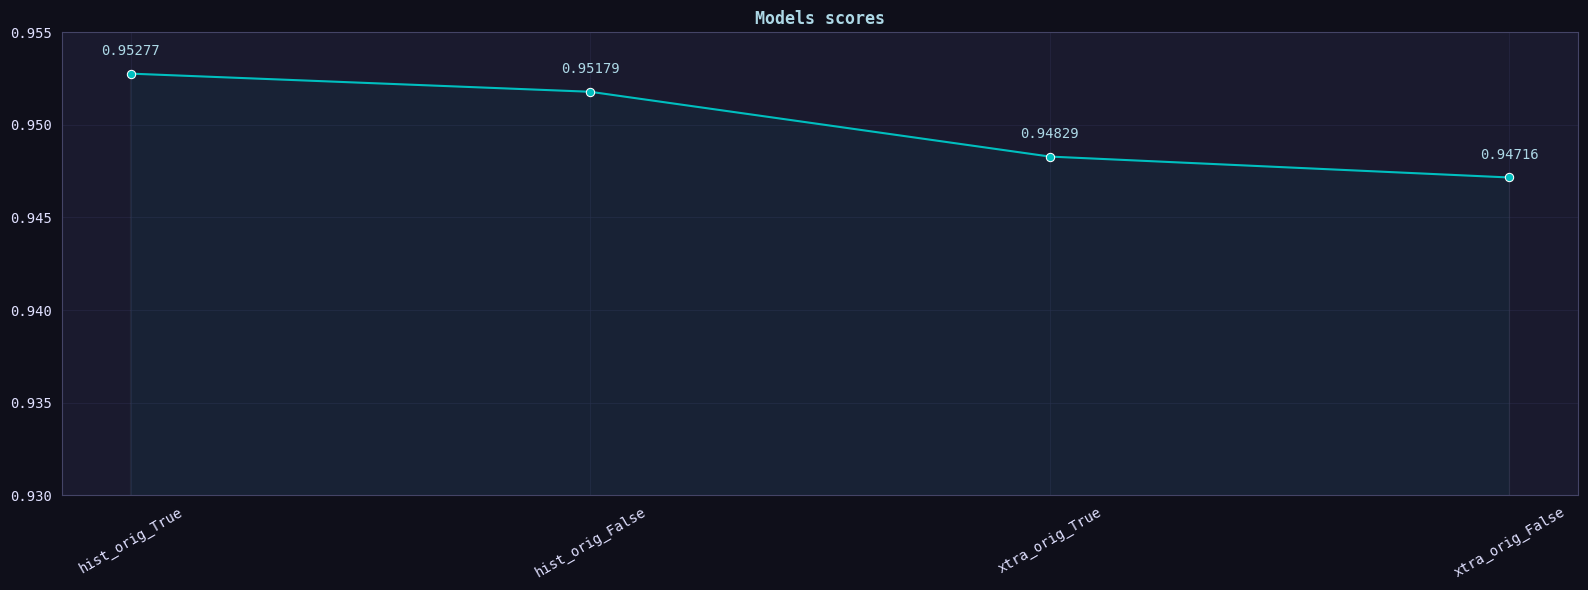

In [36]:
## -- Get Scores --
all_model_scores = {}
all_scores = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y
            all_scores.append(float(y))

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_model_scores, marker='o')

ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.05)
ax.set_title('Models scores', fontweight='semibold')
ax.tick_params('x', rotation=30)
ax.set_ylim(0.93, 0.955)

for i, s in enumerate(all_model_scores.values()):
    ax.text(float(i), s+1e-3, s, ha='center', va='baseline')

plt.tight_layout()
plt.show()

In [37]:
all_model_scores

{'hist_orig_True': np.float64(0.95277),
 'hist_orig_False': np.float64(0.95179),
 'xtra_orig_True': np.float64(0.94829),
 'xtra_orig_False': np.float64(0.94716)}

hist_orig_True_95277 saved!


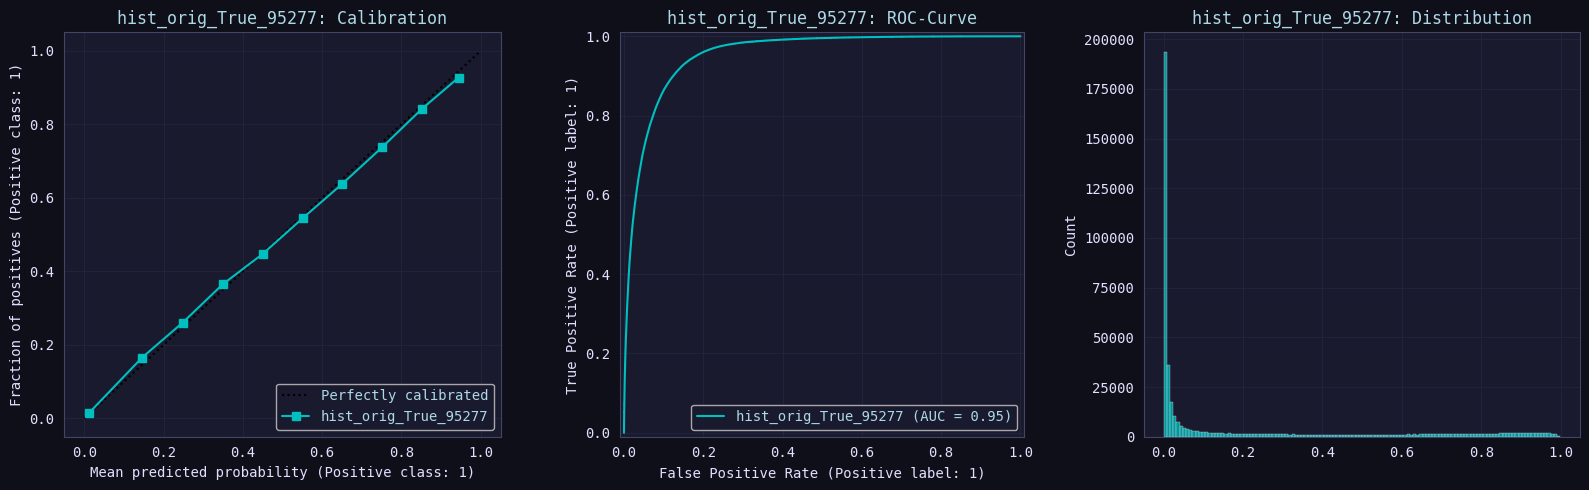


hist_orig_False_95179 saved!


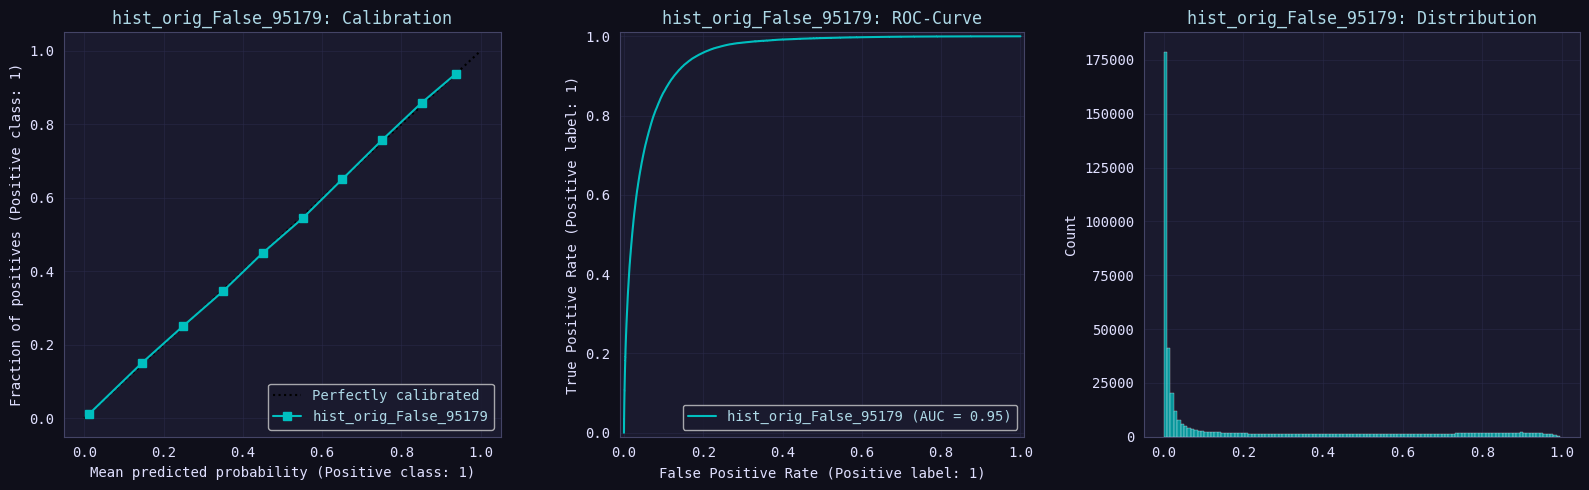


xtra_orig_True_94829 saved!


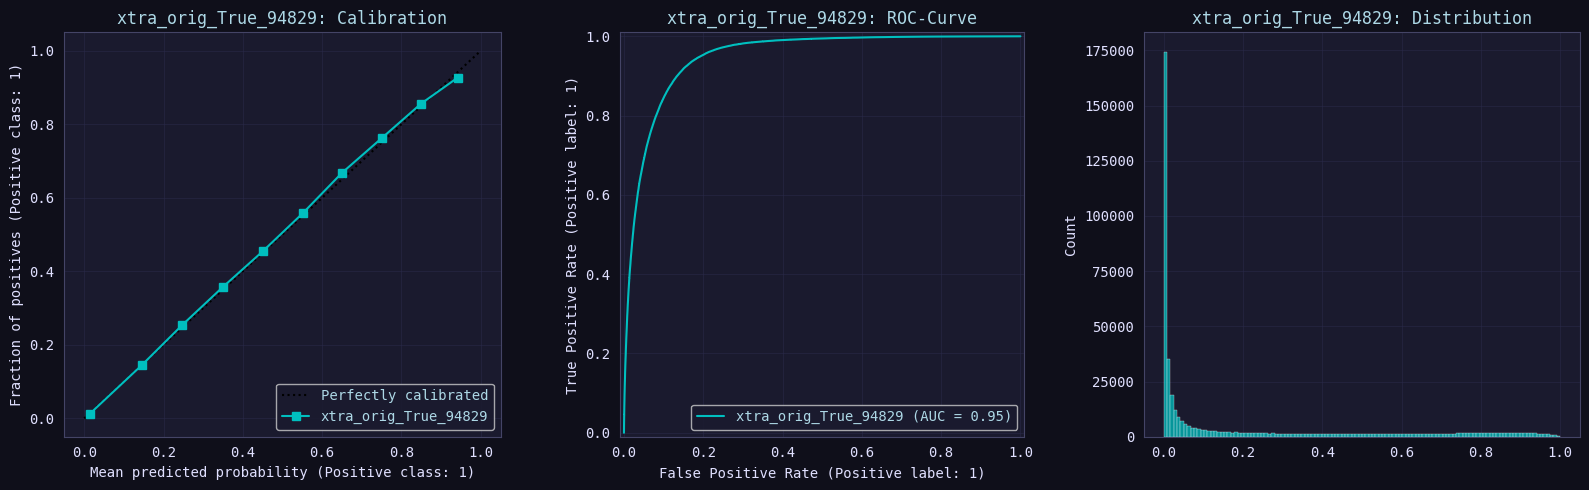


xtra_orig_False_94716 saved!


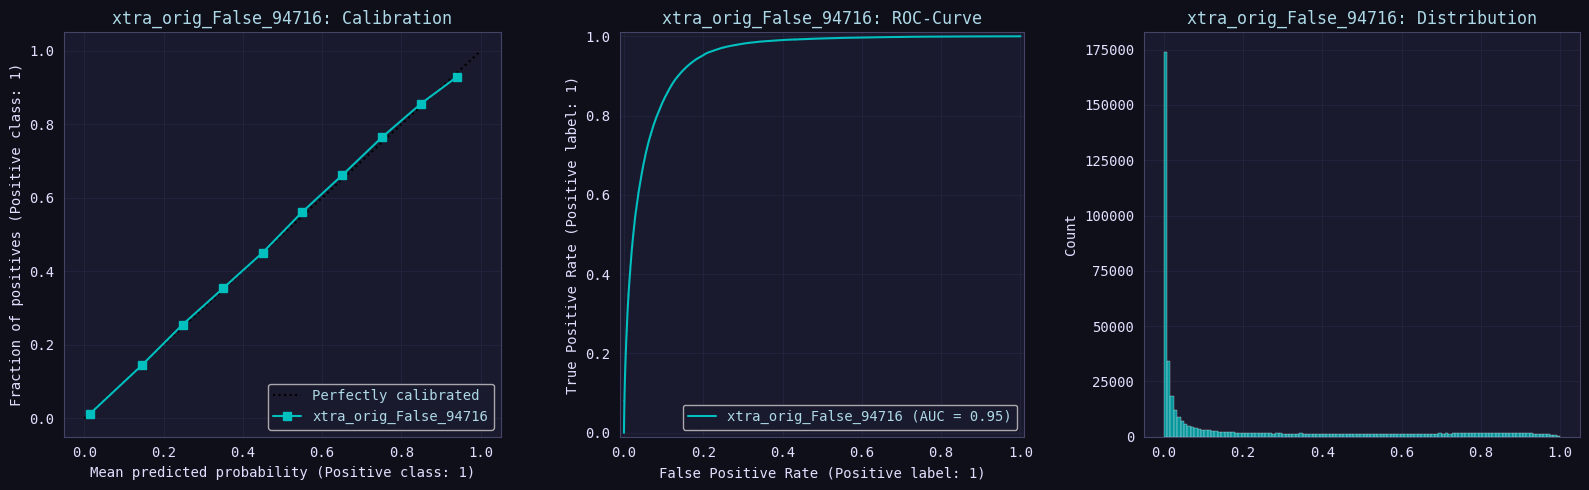

In [38]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_model_predictions.items()):
    for key_, data_ in v.items():
        if key_ == 'oof_preds':
            # Save oof predictions --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f'{n} saved!')

            # Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [39]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f'submit_base_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')
            model_results[n] = y

print()
pd.DataFrame(model_results).head(10)

hist_orig_True_95277 saved! (188165,)
hist_orig_False_95179 saved! (188165,)
xtra_orig_True_94829 saved! (188165,)
xtra_orig_False_94716 saved! (188165,)



,hist_orig_True_95277,hist_orig_False_95179,xtra_orig_True_94829,xtra_orig_False_94716
0,0.003085,0.004356,0.005530,0.004487
1,0.030514,0.006562,0.074580,0.004813
2,0.004065,0.003304,0.002847,0.002001
3,0.251544,0.185992,0.333532,0.338090
4,0.879146,0.871020,0.953580,0.943903
5,0.300811,0.210522,0.139873,0.109110
6,0.000635,0.001136,0.000213,0.000080
7,0.001097,0.002786,0.001053,0.001233
8,0.009007,0.018247,0.010583,0.009750
9,0.000675,0.000785,0.005470,0.005702


In [40]:
try:
    import shap
except:
    %pip install -q -U shap
    import shap

print(f"Shap version: {shap.__version__}")

Shap version: 0.51.0


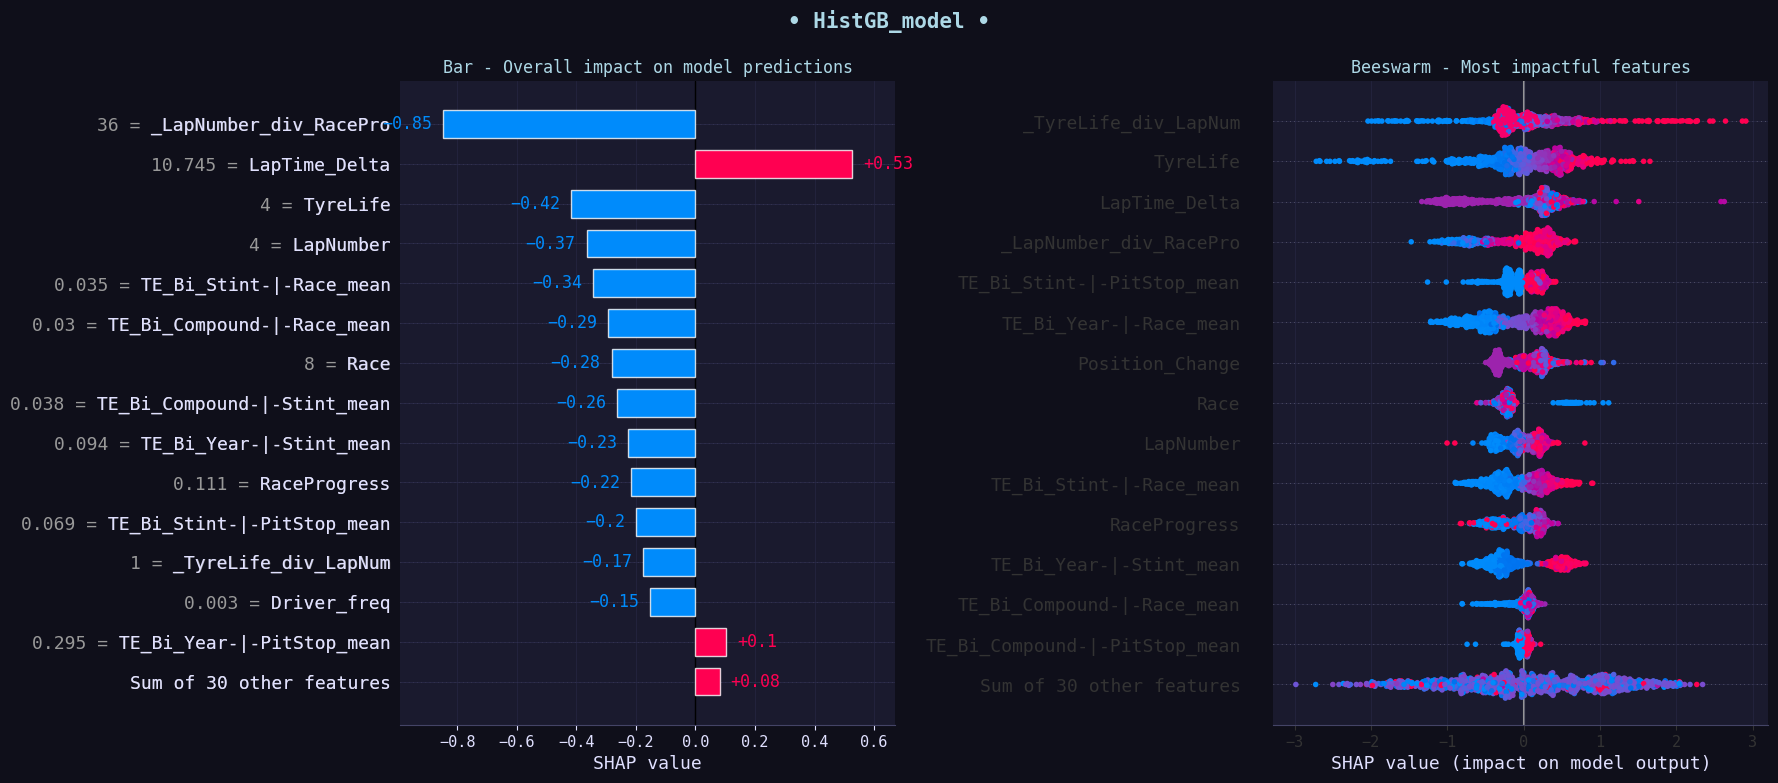

In [41]:
## -- Plot Shap values --
hist_m = all_model_predictions[list(all_model_predictions.keys())[0]]
MAX = 15

## -- Shap Explainer --
explainer = shap.TreeExplainer(hist_m['model'])
explanation = explainer(hist_m['val_data'].iloc[:1000])

## -- Bar plot --
plt.subplot(121)
shap.plots.bar(
    explanation[0],
    max_display=MAX,
    show=False
)
plt.title('Bar - Overall impact on model predictions')

## -- Beeswarm plot --
plt.subplot(122)
shap.plots.beeswarm(
    explanation,
    max_display=MAX,
    order=explanation.abs.max(0),
    color_bar=False,
    plot_size=(18, 8),
    show=False,
)

plt.title('Beeswarm - Most impactful features')

plt.suptitle('• HistGB_model •', fontweight='semibold', fontsize=15)
plt.tight_layout(pad=1.5)
plt.show()